#  Módulo 1 Utilización, procesamiento y visualización de grandes volúmenes de datos (Portafolio Análisis)

## ETL y Entrenamiento

Dataset tomado de: https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews/data?select=train.csv

Se seleccionó un dataset de reseñas de productos en la página web de Amazon.com, con un total de 4,000,000 reseñas correspondientes a distintos productos.

El primer paso consistió en una instalación de Apache Spark, en su versión 3.5.7, junto con la configuración de sus variables de entorno. Posteriormente, se importarton las dependencias necesarias y se creó una sesión de Spark.

In [1]:
# 0) Prerrequisitos para utilizar Spark
!sudo apt update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz
!tar xf spark-3.5.7-bin-hadoop3.tgz

# Variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.7-bin-hadoop3"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "bin")
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "sbin")


# 1) Instalación de PySpark
!pip install matplotlib pandas --quiet
!pip install -q findspark
!pip install pyspark

# 2) Importar librerías y montar Google Drive
from google.colab import drive
import tarfile
import findspark
import pandas as pd
import seaborn as sns
from pyspark import SparkConf
from pyspark.ml import Pipeline
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import size, col, when, explode, desc
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, SQLTransformer

import matplotlib.pyplot as plt
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Inteligencia Artificial/Big Data
%ls

findspark.init()
findspark.find()

conf = (SparkConf()
    .setAppName("OptimizedPipeline")
    .setMaster("local[*]")
    .set("spark.driver.memory", "8g")
    .set("spark.executor.memory", "8g")
    .set("spark.sql.shuffle.partitions", "4")
    .set("spark.default.parallelism", "4")
)


# 3) Crear sesión Spark
spark_session = SparkSession.builder.config(conf=conf).appName("Reto_Modulo_1").getOrCreate()
spark_session
print("Sesión Spark creada")

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 384 kB in 3s (151 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
42 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skip

El dataset original se encuentra en formato .tgz, por lo que se procedió a descomprimirlo. Este paso solo se requiere correr una vez, y, una vez terminado este paso, nos devuelve dos archivos, un **train.csv**, con un peso de 1.48GB, y un **test.csv**, con un tamaño de 167MB.

In [2]:
# 4) Descomprimir el archivo .tgz
# SOLO CORRER UNA VEZ!

# reviews = tarfile.open('amazon_review_polarity_csv.tgz')
# reviews.extractall()
# reviews.close()

%ls

amazon_review_polarity_csv/            spark-3.5.1-bin-hadoop3/
amazon_review_polarity_csv.tgz         spark-3.5.1-bin-hadoop3.tgz
df_train_spark3/                       spark-3.5.7-bin-hadoop3/
model_summary.csv                      spark-3.5.7-bin-hadoop3.tgz
model_summary.gsheet                   spark-3.5.7-bin-hadoop3.tgz.1
sentiment_predictions_for_tableau.csv  spark-3.5.7-bin-hadoop3.tgz.2


Dado que el dataset ya viene separado en archivos de train y test, con 3,600,000 y 400,000 registros, respectivamente.

Dado que son demasiados registros para una instancia de Colab Free, se opta por entrenar el modelo con 100,000 reseñas, tomando un grupo de prueba de 50,000 reseñas más. Esto puede aumentarse fácilmente si el modelo corre durante más tiempo.

In [3]:
df_train = spark_session.read.csv('amazon_review_polarity_csv/train.csv', header=False, inferSchema=True)
df_test = spark_session.read.csv('amazon_review_polarity_csv/test.csv', header=False, inferSchema=True)

# 5) Eliminar datos con celdas vacías
df_train = df_train.dropna()
df_test = df_test.dropna()


# Tomaremos un conjunto de datos más manejable para Colab Free
df_train = df_train.limit(100000)
df_test = df_test.limit(50000)

# 6) Inspección rápida
df_train.printSchema()
print("-----------------------\n")
df_train.show()
print("-----------------------\n")
df_train.describe().show()

# 7) Eliminar datos con celdas vacías
df_train = df_train.dropna()

root
 |-- _c0: integer (nullable = true)
 |-- _c1: string (nullable = true)
 |-- _c2: string (nullable = true)

-----------------------

+---+--------------------+--------------------+
|_c0|                 _c1|                 _c2|
+---+--------------------+--------------------+
|  2|Stuning even for ...|This sound track ...|
|  2|The best soundtra...|I'm reading a lot...|
|  2|            Amazing!|"This soundtrack ...|
|  2|Excellent Soundtrack|I truly like this...|
|  2|Remember, Pull Yo...|If you've played ...|
|  2|an absolute maste...|I am quite sure a...|
|  1|        Buyer beware|"This is a self-p...|
|  2|      Glorious story|I loved Whisper o...|
|  2|    A FIVE STAR BOOK|I just finished r...|
|  2|Whispers of the W...|This was a easy t...|
|  1|          The Worst!|A complete waste ...|
|  2|          Great book|This was a great ...|
|  2|          Great Read|I thought this bo...|
|  1|           Oh please|I guess you have ...|
|  1|Awful beyond belief!|"I feel I have to...|

Dado que el modelo solo verá las reseñas, no se le dará un uso a la columna de títulos, por lo que se procede a eliminar.

In [4]:
#8) Eliminar columna de título de la reseña, pues no se utiliza
df_train = df_train.drop("_c1")
df_train.show()

+---+--------------------+
|_c0|                 _c2|
+---+--------------------+
|  2|This sound track ...|
|  2|I'm reading a lot...|
|  2|"This soundtrack ...|
|  2|I truly like this...|
|  2|If you've played ...|
|  2|I am quite sure a...|
|  1|"This is a self-p...|
|  2|I loved Whisper o...|
|  2|I just finished r...|
|  2|This was a easy t...|
|  1|A complete waste ...|
|  2|This was a great ...|
|  2|I thought this bo...|
|  1|I guess you have ...|
|  1|"I feel I have to...|
|  1|It's glaringly ob...|
|  2|"When you hear fo...|
|  2|After I had a DVT...|
|  2|Excellent product...|
|  1|sizes are much sm...|
+---+--------------------+
only showing top 20 rows



Finalmente, se renombran las dos columnas restantes, "_c0", se renombra a Rating, y "_c2" pasa a ser Review.

Este conjunto de modificaciones nos permite acelerar el entrenamiento del modelo, manteniendo al mismo tiempo un gran volumen de datos.

In [5]:
# 9) Renombrar columnas
df_train = df_train.withColumnRenamed("_c0", "Rating").withColumnRenamed("_c2", "Review")
df_train = df_train.withColumn(
    "Rating", when(col("Rating") == 1, 0).otherwise(1).cast(DoubleType())
)

Esta sección es opcional, pero nos permite exportar el dataframe actual para saltar esta sección en ejecuciones futuras.

In [6]:
# 10) Exportar DF a CSV usando Spark
#df_train.write.csv('df_train_spark3', header=True, mode='overwrite')

In [7]:
# Aplicar los mismos cambios a csv de test

# 11) Inspección rápida
df_test.printSchema()
print("-----------------------\n")
df_test.show()
print("-----------------------\n")
df_test.describe().show()

# 12) Eliminar datos con celdas vacías
df_test = df_test.dropna()

# 13) Eliminar columna de título de la reseña, pues no se utiliza
df_test = df_test.drop("_c1")
df_test.show()

# 14) Renombrar columnas
df_test = df_test.withColumnRenamed("_c0", "Rating").withColumnRenamed("_c2", "Review")

df_test = df_test.withColumn(
    "Rating", when(col("Rating") == 1, 0).otherwise(1).cast(DoubleType())
)

root
 |-- _c0: integer (nullable = true)
 |-- _c1: string (nullable = true)
 |-- _c2: string (nullable = true)

-----------------------

+---+--------------------+--------------------+
|_c0|                 _c1|                 _c2|
+---+--------------------+--------------------+
|  2|            Great CD|"My lovely Pat ha...|
|  2|One of the best g...|Despite the fact ...|
|  1|Batteries died wi...|I bought this cha...|
|  2|works fine, but M...|Check out Maha En...|
|  2|Great for the non...|Reviewed quite a ...|
|  1|DVD Player crappe...|I also began havi...|
|  1|      Incorrect Disc|I love the style ...|
|  1|DVD menu select p...|I cannot scroll t...|
|  2|Unique Weird Orie...|"Exotic tales of ...|
|  1|"Not an ""ultimat...|Firstly,I enjoyed...|
|  2|Great book for tr...|I currently live ...|
|  1|                Not!|If you want to li...|
|  1|     A complete Bust|"This game requir...|
|  2|TRULY MADE A DIFF...|I have been using...|
|  1|didn't run off of...|Was hoping that t...|

In [8]:
df_train.cache()

# Transformador SQL para convertir Rating a binario y cambiar tipo a Double
sql_transformer = SQLTransformer(
    statement="""
        SELECT *,
        CAST(CASE WHEN Rating = 1 THEN 0 ELSE 1 END AS DOUBLE) AS label
        FROM __THIS__
    """
)

# Creación del pipeline completo para NLP
tokenizer = Tokenizer(inputCol="Review", outputCol="words")
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=10000)
idf = IDF(inputCol="rawFeatures", outputCol="features", minDocFreq=5)
lr = LogisticRegression(featuresCol="features", labelCol="Rating", maxIter=50)

pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])

# Grid de parámetros, poco consumo de recursos
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1])
             .addGrid(lr.elasticNetParam, [0.0, 0.5])
             .build())

# CrossValidator optimizado con paralelismo y bajo uso de recursos
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol="Rating"),
    numFolds=2,      # menor número de validaciones
    parallelism=2    # usa 2 hilos locales
)

# Entrenamiento del modelo
cvModel = crossval.fit(df_train)

In [9]:
df_test.cache()

# Transformador SQL para convertir Rating a binario y cambiar tipo a Double
sql_transformer = SQLTransformer(
    statement="""
        SELECT *,
        CAST(CASE WHEN Rating = 1 THEN 0 ELSE 1 END AS DOUBLE) AS label
        FROM __THIS__
    """
)

# Creación del pipeline completo para NLP
tokenizer = Tokenizer(inputCol="Review", outputCol="words")
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=5000)
idf = IDF(inputCol="rawFeatures", outputCol="features", minDocFreq=5)
lr = LogisticRegression(featuresCol="features", labelCol="Rating", maxIter=50)

pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])

# Grid de parámetros, poco consumo de recursos
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1])
             .addGrid(lr.elasticNetParam, [0.0, 0.5])
             .build())

# CrossValidator optimizado con paralelismo y bajo uso de recursos
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol="Rating"),
    numFolds=2,      # menor número de validaciones
    parallelism=2    # usa 2 hilos locales
)

# Entrenar el modelo con validación cruzada
cvModel = crossval.fit(df_train)

# Evaluación con datos de prueba
# El cvModel ya contiene todas las transformaciones del pipeline
# Solo necesitamos aplicar el modelo completo a los datos de prueba
predictions = cvModel.transform(df_test)

# Evaluar el modelo
evaluator = BinaryClassificationEvaluator(labelCol="prediction")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy on test data = {accuracy}")

Accuracy on test data = 1.0


## Estadísticas del dataset

### Uso de más métricas para evaluar el desempeño del modelo, usando los siguientes datos:
- ROC Curve
- Precision
- Recall
- F1-Score

In [10]:
# Selección segura de la columna de etiqueta (label)
label_col = "label" if "label" in predictions.columns else "Rating"  # ajusta si tu etiqueta tiene otro nombre

from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

# Evaluar modelo usando BinaryClassificationEvaluator
binary_evaluator = BinaryClassificationEvaluator(
    labelCol=label_col,  # Ahora usa la etiqueta correcta
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = binary_evaluator.evaluate(predictions)
print(f"Area Under ROC (AUC) en datos de prueba = {auc}")

# Preparación de los datos para MulticlassMetrics, que recibe un RDD con (prediction, label)
predictionAndLabels = predictions.select("prediction", label_col).rdd.map(
    lambda row: (float(row["prediction"]), float(row[label_col]))
)

# Instancia del objeto de métricas
metrics = MulticlassMetrics(predictionAndLabels)

# Métricas globales
accuracy = metrics.accuracy
print(f"Exactitud (Accuracy) en datos de prueba = {accuracy}")

# Estadísticas por clase
# Para clasificación binaria, metrics.precision(1.0), metrics.recall(1.0) y metrics.fMeasure(1.0) corresponden a la clase positiva (etiqueta 1),
# y metrics.precision(0.0), metrics.recall(0.0) y metrics.fMeasure(0.0) corresponden a la clase negativa (etiqueta 0).
positive_class_label = 1.0
negative_class_label = 0.0

precision_pos = metrics.precision(positive_class_label)
recall_pos = metrics.recall(positive_class_label)
f1_pos = metrics.fMeasure(positive_class_label)

precision_neg = metrics.precision(negative_class_label)
recall_neg = metrics.recall(negative_class_label)
f1_neg = metrics.fMeasure(negative_class_label)

print(f"\nMétricas para la Clase Positiva (etiqueta {int(positive_class_label)}):")
print(f"  Precisión = {precision_pos}")
print(f"  Exhaustividad (Recall) = {recall_pos}")
print(f"  F1-Score = {f1_pos}")

print(f"\nMétricas para la Clase Negativa (etiqueta {int(negative_class_label)}):")
print(f"  Precisión = {precision_neg}")
print(f"  Exhaustividad (Recall) = {recall_neg}")
print(f"  F1-Score = {f1_neg}")

# Matriz de confusión
print("\nMatriz de confusión:")
print(metrics.confusionMatrix().toArray())

Area Under ROC (AUC) en datos de prueba = 0.8823282088648692


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Exactitud (Accuracy) en datos de prueba = 0.80226

Métricas para la Clase Positiva (etiqueta 1):
  Precisión = 0.7922626910737876
  Exhaustividad (Recall) = 0.8272641286356113
  F1-Score = 0.8093851819005572

Métricas para la Clase Negativa (etiqueta 0):
  Precisión = 0.8135290363752393
  Exhaustividad (Recall) = 0.7764963859335662
  F1-Score = 0.7945814547796639

Matriz de confusión:
[[19122.  5504.]
 [ 4383. 20991.]]


In [11]:
# Agrupar y contar por el Rating'
rating_counts = df_train.groupBy("Rating").count()

# Transformar a DF de Pandas para imprimir de manera amigable
rating_counts_pandas = rating_counts.toPandas()

print("Distribución de clases:")
display(rating_counts_pandas)

Distribución de clases:


,Rating,count
0,1.0,51267
1,0.0,48733


In [12]:
# Volver a tokenizar el texto para recuperar la columna 'words'
tokenizer = Tokenizer(inputCol="Review", outputCol="words")
df_train_with_words = tokenizer.transform(df_train)

# Calcular la longitud de cada reseña en número de tokens
df_train_with_token_length = df_train_with_words.withColumn("Review_Token_Length", size(col("words")))

# Calcular estadísticas descriptivas de las longitudes de las reseñas
review_length_stats = df_train_with_token_length.select("Review_Token_Length").describe()

# Imprimir las estadísticas
print("Estadísticas descriptivas para la longitud (en tokens) de las reseñas:")
review_length_stats.show()

Estadísticas descriptivas para la longitud (en tokens) de las reseñas:
+-------+-------------------+
|summary|Review_Token_Length|
+-------+-------------------+
|  count|             100000|
|   mean|           67.10845|
| stddev|  40.16910061432704|
|    min|                  1|
|    max|                240|
+-------+-------------------+



### Encontrar las palabras más comunes

In [13]:
# Aplicar un flatten la columna 'words'
word_counts = df_train_with_words.select(explode("words").alias("word"))

# Contar la frecuencia de cada palabra
word_counts = word_counts.groupBy("word").count()

# Ordenar por conteo en orden descendente y mostrar las 20 más frecuentes
most_common_words = word_counts.orderBy(desc("count"))
print("20 palabras con más apariciones:")
most_common_words.show(20, truncate=False)

20 palabras con más apariciones:
+----+------+
|word|count |
+----+------+
|the |345388|
|and |184005|
|i   |173121|
|a   |170290|
|to  |163710|
|of  |141133|
|this|124890|
|is  |123966|
|it  |116986|
|in  |81176 |
|that|67695 |
|for |66806 |
|was |64143 |
|you |49126 |
|with|47583 |
|but |46668 |
|not |46475 |
|on  |44212 |
|have|43998 |
|my  |41082 |
+----+------+
only showing top 20 rows



### Comparar el recuento de palabras por clase

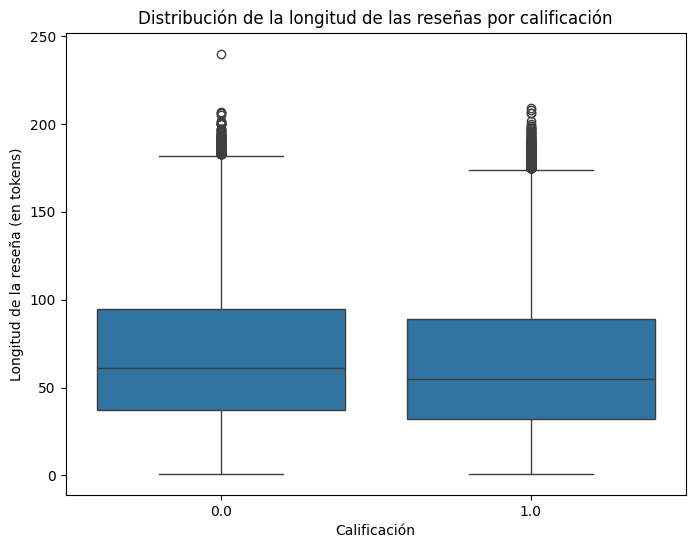

In [14]:
# Convertir el DataFrame de PySpark a un DataFrame de Pandas
df_train_with_token_length_pandas = df_train_with_token_length.select("Rating", "Review_Token_Length").toPandas()

# Crear un diagrama de caja (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Rating", y="Review_Token_Length", data=df_train_with_token_length_pandas)

# Agregar título y etiquetas
plt.title("Distribución de la longitud de las reseñas por calificación")
plt.xlabel("Calificación")
plt.ylabel("Longitud de la reseña (en tokens)")

# Mostrar gráfico
plt.show()

### Resumen de la ejecución

In [15]:
# Collect the evaluation metrics
metrics_summary = {
    "AUC": auc,
    "Precisión global": accuracy,
    "Precisión clase positiva": precision_pos,
    "Recall clase positiva": recall_pos,
    "Puntaje F1 clase positiva": f1_pos,
    "Precisión clase negativa": precision_neg,
    "Recall clase negativa": recall_neg,
    "Puntaje F1 clase negativa": f1_neg
}

# Imprimir el diccionario para verificar las métricas recopiladas
print(metrics_summary)

{'AUC': 0.8823282088648692, 'Precisión global': 0.80226, 'Precisión clase positiva': 0.7922626910737876, 'Recall clase positiva': 0.8272641286356113, 'Puntaje F1 clase positiva': 0.8093851819005572, 'Precisión clase negativa': 0.8135290363752393, 'Recall clase negativa': 0.7764963859335662, 'Puntaje F1 clase negativa': 0.7945814547796639}


In [16]:
# Convertir los DataFrames a un formato adecuado
rating_counts_list = rating_counts_pandas.to_dict('records')
review_length_stats_list = review_length_stats.toPandas().to_dict('records')
most_common_words_list = most_common_words.limit(20).toPandas().to_dict('records')

# Crear el diccionario de resumen completo del modelo
model_summary = {
    "Métricas de evaluación": metrics_summary,
    "Distribución de clases": rating_counts_list,
    "Estadísticas de longitud de reseñas": review_length_stats_list,
    "Top 20 palabras más comunes": most_common_words_list
}

# Mostrar el diccionario
print("Diccionario resumen del modelo:")
display(model_summary)

Diccionario resumen del modelo:


{'Métricas de evaluación': {'AUC': 0.8823282088648692,
  'Precisión global': 0.80226,
  'Precisión clase positiva': 0.7922626910737876,
  'Recall clase positiva': 0.8272641286356113,
  'Puntaje F1 clase positiva': 0.8093851819005572,
  'Precisión clase negativa': 0.8135290363752393,
  'Recall clase negativa': 0.7764963859335662,
  'Puntaje F1 clase negativa': 0.7945814547796639},
 'Distribución de clases': [{'Rating': 1.0, 'count': 51267},
  {'Rating': 0.0, 'count': 48733}],
 'Estadísticas de longitud de reseñas': [{'summary': 'count',
   'Review_Token_Length': '100000'},
  {'summary': 'mean', 'Review_Token_Length': '67.10845'},
  {'summary': 'stddev', 'Review_Token_Length': '40.16910061432704'},
  {'summary': 'min', 'Review_Token_Length': '1'},
  {'summary': 'max', 'Review_Token_Length': '240'}],
 'Top 20 palabras más comunes': [{'word': 'the', 'count': 345388},
  {'word': 'and', 'count': 184005},
  {'word': 'i', 'count': 173121},
  {'word': 'a', 'count': 170290},
  {'word': 'to', 'co

## Generar csv, transformando a un DataFrame de Pandas y exportando a CSV


In [17]:
# Hacer faltten al diccionario para hacer más sencilla la creación del DataFrame
flattened_summary = {}

# Agregar las métricas de evaluación
for key, value in model_summary["Métricas de evaluación"].items():
    flattened_summary[f"Métricas de evaluación - {key}"] = [value]

# Agregar la distribución de clases
for item in model_summary["Distribución de clases"]:
    flattened_summary[f"Distribución de clases - Calificación {item['Rating']} (Conteo)"] = [item['count']]

# Agregar stats de longitud de reseñas
for item in model_summary["Estadísticas de longitud de reseñas"]:
    # Usar la clave del resumen (por ejemplo, 'count', 'mean') como parte del nombre de la columna
    flattened_summary[f"Estadísticas de longitud de reseñas - {item['summary']}"] = [item['Review_Token_Length']]

# Agregar las 20 palabras más comunes con una sola comprensión de diccionario
flattened_summary.update({
    f"Palabra común {i+1} - {k.capitalize()}": [v]
    for i, item in enumerate(model_summary["Top 20 palabras más comunes"])
    for k, v in item.items()
})

summary_df = pd.DataFrame(flattened_summary)

# Ruta y el nombre del archivo CSV de salida
output_csv_path = 'model_summary.csv'

# Exportar el DataFrame de Pandas a un archivo CSV
summary_df.to_csv(output_csv_path, index=False)

# Verificar la creación del archivo
print(f"Resumen del modelo exportado a {output_csv_path}")
%ls

Resumen del modelo exportado a model_summary.csv
amazon_review_polarity_csv/            spark-3.5.1-bin-hadoop3/
amazon_review_polarity_csv.tgz         spark-3.5.1-bin-hadoop3.tgz
df_train_spark3/                       spark-3.5.7-bin-hadoop3/
model_summary.csv                      spark-3.5.7-bin-hadoop3.tgz
model_summary.gsheet                   spark-3.5.7-bin-hadoop3.tgz.1
sentiment_predictions_for_tableau.csv  spark-3.5.7-bin-hadoop3.tgz.2


### Creación del CSV de predicciones

In [18]:
# Convert the Spark DataFrame to a Pandas DataFrame
predictions_pandas = predictions.toPandas()

# Define the path and filename for the output CSV file
output_predictions_path = 'sentiment_predictions_for_tableau.csv'

# Export the Pandas DataFrame to a CSV file
predictions_pandas.to_csv(output_predictions_path, index=False)

print(f"Predictions exported to {output_predictions_path}")
%ls

Predictions exported to sentiment_predictions_for_tableau.csv
amazon_review_polarity_csv/            spark-3.5.1-bin-hadoop3/
amazon_review_polarity_csv.tgz         spark-3.5.1-bin-hadoop3.tgz
df_train_spark3/                       spark-3.5.7-bin-hadoop3/
model_summary.csv                      spark-3.5.7-bin-hadoop3.tgz
model_summary.gsheet                   spark-3.5.7-bin-hadoop3.tgz.1
sentiment_predictions_for_tableau.csv  spark-3.5.7-bin-hadoop3.tgz.2
